# Airbnb Analytics — Database-Driven Insights

This notebook connects to the `airbnb_analytics` MySQL database, executes analytical queries, generates visualisations, and exports results to `exports/` (CSVs) and `docs/` (plots) for reporting.

In [45]:
## 1. Imports and configuration
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
from datetime import datetime

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_USER = "root"  # change if needed
DB_NAME = "airbnb_analytics"  # keep if this is your DB name
DB_PASS = getpass(f"MySQL password for {DB_USER}@{DB_HOST}:{DB_PORT}: ")

RUN_DATE = datetime.now().strftime("%Y-%m-%d")

os.makedirs("../exports", exist_ok=True)
os.makedirs("../docs", exist_ok=True)

In [46]:
## 2. Connect to MySQL database
try:
    conn = mysql.connector.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME)
except mysql.connector.Error as err:
    raise SystemExit

C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\3645349257.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_host_revenue = pd.read_sql(query_host_revenue, conn)
C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\3645349257.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_host_revenue, x="total_revenue", y="host_name", palette="viridis")


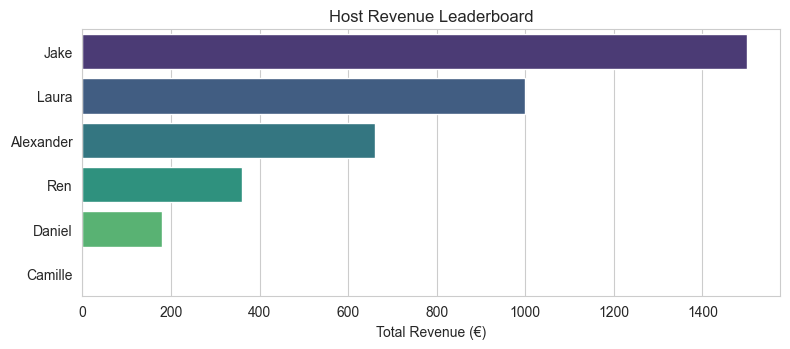

In [47]:
## 3. Query: Host revenue leaderboard
query_host_revenue = """
SELECT h.name AS host_name, COALESCE(SUM(p.paid_amount),0) AS total_revenue
FROM Host h
JOIN Listing l ON l.host_id = h.id
JOIN Booking b ON b.listing_id = l.id
LEFT JOIN Payment p ON p.booking_id = b.id AND p.status = 'paid'
GROUP BY h.name
ORDER BY total_revenue DESC;
"""
df_host_revenue = pd.read_sql(query_host_revenue, conn)

csv_path = f"../exports/host_revenue_{RUN_DATE}.csv"
png_path = f"../docs/host_revenue_leaderboard_{RUN_DATE}.png"

df_host_revenue.to_csv(csv_path, index=False)

plt.figure(figsize=(8, max(3, 0.6*len(df_host_revenue))))
sns.barplot(data=df_host_revenue, x="total_revenue", y="host_name", palette="viridis")
plt.title("Host Revenue Leaderboard")
plt.xlabel("Total Revenue (€)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.show()

C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\2639072397.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_mv_city = pd.read_sql(query_mv_city, conn)
C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\2639072397.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mv_city, x="total_bookings", y="city", ax=ax[0], palette="coolwarm")
C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\2639072397.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mv_city, x="total_revenue", y="city", ax=ax[1], palette="coo

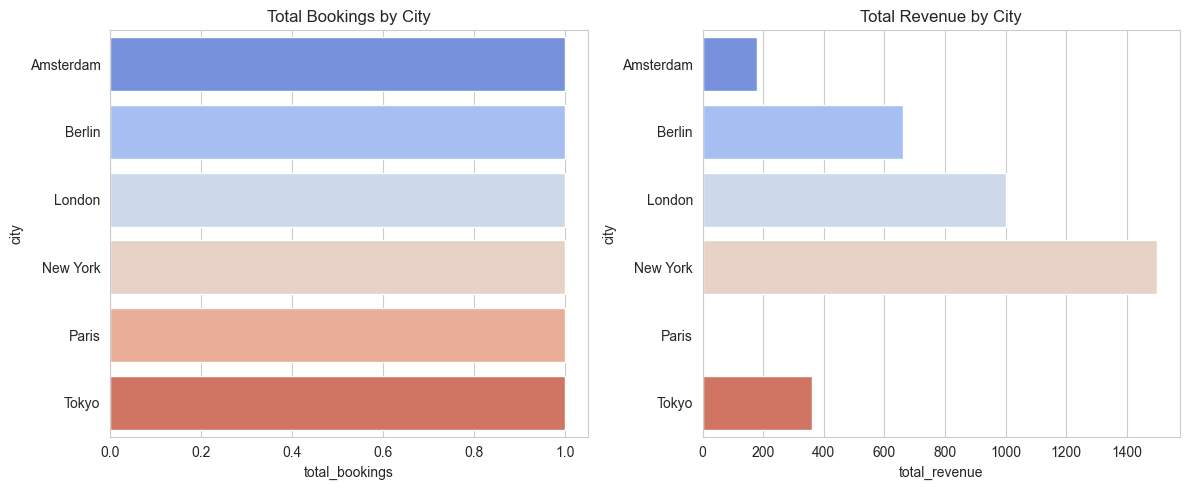

In [48]:
## 4. Query: City performance (materialized view)
query_mv_city = "SELECT * FROM mv_city_performance;"
df_mv_city = pd.read_sql(query_mv_city, conn)

csv_path = f"../exports/city_performance_{RUN_DATE}.csv"
png_path = f"../docs/city_performance_{RUN_DATE}.png"

df_mv_city.to_csv(csv_path, index=False)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(data=df_mv_city, x="total_bookings", y="city", ax=ax[0], palette="coolwarm")
ax[0].set_title("Total Bookings by City")
sns.barplot(data=df_mv_city, x="total_revenue", y="city", ax=ax[1], palette="coolwarm")
ax[1].set_title("Total Revenue by City")
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.show()

C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\2636585522.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_amenities = pd.read_sql(query_amenities, conn)
C:\Users\Isabella\AppData\Local\Temp\ipykernel_11268\2636585522.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_amenities, x="listings_with_amenity", y="label", palette="mako")


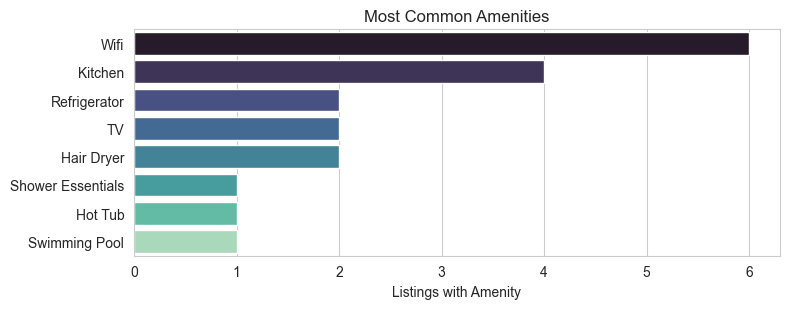

In [49]:
## 5. Query: Most common amenities
query_amenities = """
SELECT a.label, COUNT(la.id) AS listings_with_amenity
FROM Amenity a
JOIN ListingAmenity la ON la.amenity_id = a.id
GROUP BY a.label
ORDER BY listings_with_amenity DESC;
"""
df_amenities = pd.read_sql(query_amenities, conn)

csv_path = f"../exports/amenities_frequency_{RUN_DATE}.csv"
png_path = f"../docs/amenities_frequency_{RUN_DATE}.png"

df_amenities.to_csv(csv_path, index=False)

plt.figure(figsize=(8, max(3, 0.4*len(df_amenities))))
sns.barplot(data=df_amenities, x="listings_with_amenity", y="label", palette="mako")
plt.title("Most Common Amenities")
plt.xlabel("Listings with Amenity")
plt.ylabel("")
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.show()

In [50]:
conn.close()